# WinCLIP MVTec Experiment

MVTec 데이터셋에서 `models.winclip.WinCLIP`을 PatchCore와 같은 `fit / predict / predict_batch` 인터페이스로 실행합니다.

In [1]:
import os
import sys

# Notebook을 MVTec 폴더 안에서 열어도 repo root 기준으로 실행되게 맞춥니다.
if os.path.basename(os.getcwd()) == "MVTec":
    os.chdir("..")

print(os.getcwd())

sys.path.append("..")

/Users/taehayeong/Desktop/lab


In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "MVTec":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import torch
import numpy as np

import config_mv
from datasets.mvtec import MyData
from models.winclip import WinCLIP
from utils.metrics import get_image_auc
from utils.visualization import show_result

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(device)

mps


In [4]:
train_data = MyData(
    config_mv.CLASS_NAME,
    phase="train",
    batch_size=config_mv.BATCH_SIZE,
    shuffle=False,
    limit=config_mv.TRAIN_LIMIT,
)

test_data = MyData(
    config_mv.CLASS_NAME,
    phase="test",
    batch_size=config_mv.BATCH_SIZE,
    shuffle=False,
    limit=config_mv.TEST_LIMIT,
    limit_per_class=config_mv.TEST_LIMIT_PER_CLASS,
)

print("class:", config_mv.CLASS_NAME)
print("train:", len(train_data), "test:", len(test_data))

class: bottle
train: 209 test: 83


In [5]:
winclip = WinCLIP(
    category=config_mv.CLASS_NAME,
    device=device,
    backbone="ViT-B-16-plus-240",
    pretrained_dataset="laion400m_e32",
    out_size_h=256,
    out_size_w=256,
    img_resize=256,
    img_cropsize=240,
    use_visual_gallery=True,
)

winclip.fit(train_data)

self.grid_size (15, 15)
fusion version: textual_visual


In [6]:
scores = []
heatmaps = []
imgs = []

for img, label in test_data:
    score, heatmap = winclip.predict(img)
    scores.append(score.item())
    heatmaps.append(heatmap)
    imgs.append(img)

print("scores:", np.round(scores, 4).tolist())

scores: [0.1132, 0.0943, 0.0916, 0.1088, 0.0803, 0.0872, 0.0897, 0.0938, 0.0949, 0.0938, 0.0987, 0.0785, 0.0897, 0.1064, 0.1397, 0.1011, 0.0979, 0.1071, 0.1055, 0.1288, 0.0736, 0.0893, 0.1089, 0.094, 0.0823, 0.0768, 0.0657, 0.0791, 0.0766, 0.1399, 0.0841, 0.0931, 0.0765, 0.0831, 0.1029, 0.0919, 0.0824, 0.1311, 0.0871, 0.0949, 0.0792, 0.1251, 0.1118, 0.0768, 0.0728, 0.0878, 0.089, 0.1086, 0.1104, 0.0964, 0.0727, 0.0745, 0.0813, 0.1071, 0.1299, 0.1123, 0.0989, 0.0845, 0.1006, 0.1201, 0.1016, 0.075, 0.1142, 0.0796, 0.0624, 0.0723, 0.0658, 0.0614, 0.0886, 0.0901, 0.0795, 0.0639, 0.0867, 0.0866, 0.0756, 0.0714, 0.124, 0.0768, 0.0837, 0.062, 0.069, 0.0838, 0.0943]


In [7]:
image_auc = get_image_auc(test_data, winclip)
print("image AUROC:", image_auc)

image AUROC: 0.792063492063492


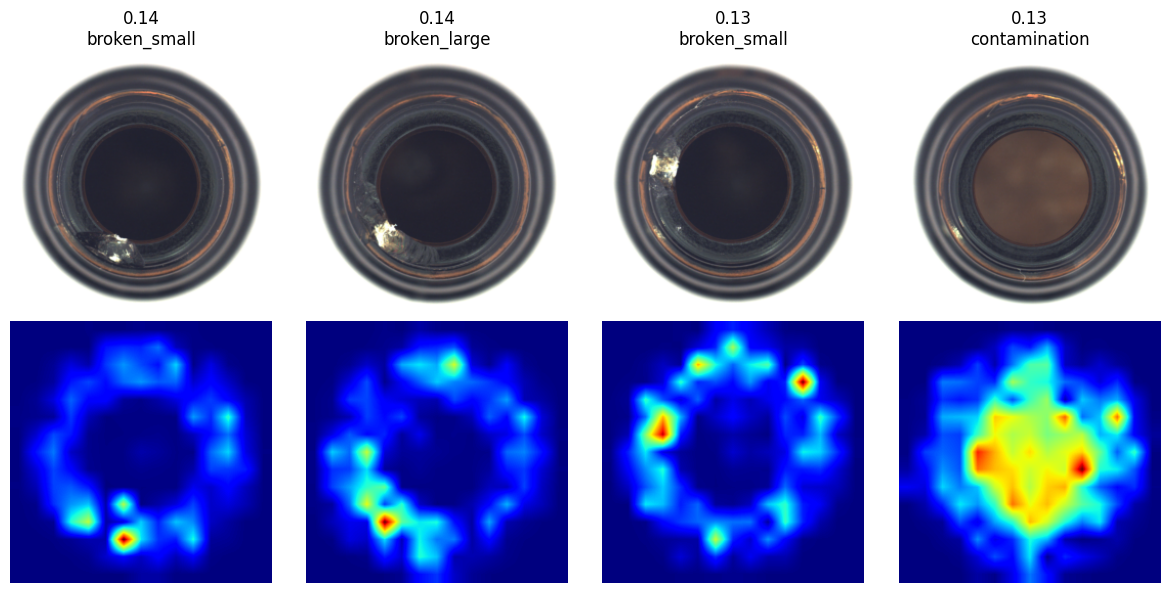

In [8]:
show_result(test_data, scores, heatmaps, k=4)